# Covariance Regime Stability

## Research Validation — Regime-Level Evidence

This notebook evaluates whether the conclusions from the baseline
covariance research remain stable across different historical market
subperiods.

Three covariance methodologies are compared:

- Sample covariance
- Fixed-intensity shrinkage
- Ledoit-Wolf shrinkage

The analysis uses the existing strictly out-of-sample covariance
experiment infrastructure.

The purpose is not to identify a universally optimal covariance
estimator, but to determine whether the observed methodological
differences are stable across historical market environments.

## Research Question

> Does the relative performance of covariance-estimation methodologies
> remain reasonably stable across different historical market periods?

### Why this matters

A methodology that performs well only during one historical period may
not provide reliable evidence of general superiority.

Regime-level analysis therefore provides an additional validation layer
beyond the baseline comparison and training-window robustness analysis.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from crypto_alpha_lab.data import load_prices
from crypto_alpha_lab.research.covariance_experiment import (
    run_covariance_experiment,
)
from crypto_alpha_lab.evaluation.covariance_comparison import (
    compare_covariance_methods,
)

In [25]:
assets = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
}

close_prices = pd.concat(
    {
        name: load_prices(
            ticker,
            "2021-01-01",
            "2025-12-31",
        )["Close"]
        for name, ticker in assets.items()
    },
    axis=1,
).dropna()

close_prices.index = pd.to_datetime(
    close_prices.index
)

close_prices = close_prices.sort_index()

close_prices.head()

,BTC,ETH,SOL
Date,,,
2021-01-01,29374.152344,730.367554,1.842084
2021-01-02,32127.267578,774.534973,1.799275
2021-01-03,32782.023438,975.507690,2.161752
2021-01-04,31971.914062,1040.233032,2.485097
2021-01-05,33992.429688,1100.006104,2.157217


In [26]:
print("Shape:", close_prices.shape)
print("Start:", close_prices.index.min())
print("End:", close_prices.index.max())
print("Assets:", close_prices.columns.tolist())

Shape: (1825, 3)
Start: 2021-01-01 00:00:00
End: 2025-12-30 00:00:00
Assets: ['BTC', 'ETH', 'SOL']


## Historical Validation Periods

We divide the available historical sample into three descriptive
subperiods.

These periods are used as research slices rather than statistically
estimated latent regimes.

The objective is to test whether methodology rankings change materially
across different historical environments.

In [27]:
periods = {
    "2021_2022": (
        "2021-01-01",
        "2022-12-31",
    ),
    "2023_2024": (
        "2023-01-01",
        "2024-12-31",
    ),
    "2025": (
        "2025-01-01",
        "2025-12-31",
    ),
}

In [28]:
# Before running experiments, we confirm that every historical period actually contains sufficient observations.
period_summary = []

for name, (start, end) in periods.items():

    subset = close_prices.loc[start:end]

    period_summary.append(
        {
            "period": name,
            "start": subset.index.min(),
            "end": subset.index.max(),
            "observations": len(subset),
        }
    )

period_summary = pd.DataFrame(
    period_summary
)

period_summary

,period,start,end,observations
0,2021_2022,2021-01-01,2022-12-31,730
1,2023_2024,2023-01-01,2024-12-31,731
2,2025,2025-01-01,2025-12-30,364


We should not blindly use the same train_size=252 and test_size=21 configuration inside the 2025 slice if doing so produces too few meaningful folds.

The purpose of 6B is comparison across periods, so each period needs enough observations for a meaningful walk-forward experiment.

For the first implementation, we'll therefore use:

In [29]:
regime_results = {}

for period_name, (start, end) in periods.items():

    period_prices = close_prices.loc[start:end].copy()

    experiments = [
        run_covariance_experiment(
            prices=period_prices,
            method="sample",
            train_size=126,
            test_size=21,
        ),
        run_covariance_experiment(
            prices=period_prices,
            method="shrinkage",
            train_size=126,
            test_size=21,
            shrinkage=0.25,
        ),
        run_covariance_experiment(
            prices=period_prices,
            method="ledoit_wolf",
            train_size=126,
            test_size=21,
        ),
    ]

    comparison = compare_covariance_methods(
        experiments,
        periods_per_year=252,
        risk_free_rate=0.0,
    )

    regime_results[period_name] = comparison

In [30]:
# Confirm all experiments are OOS

for period_name, comparison in regime_results.items():

    print(
        period_name,
        comparison.metadata["out_of_sample"],
        comparison.metadata["method_count"],
    )

2021_2022 True 3
2023_2024 True 3
2025 True 3


In [31]:
# we create a regime performance table
regime_tables = []

for period_name, comparison in regime_results.items():

    table = comparison.summary[
        [
            "total_return",
            "annualized_return",
            "annualized_volatility",
            "sharpe_ratio",
            "sortino_ratio",
            "maximum_drawdown",
            "calmar_ratio",
            "average_turnover",
        ]
    ].copy()

    table["period"] = period_name
    table["method"] = table.index

    regime_tables.append(
        table.reset_index(drop=True)
    )

regime_summary = pd.concat(
    regime_tables,
    ignore_index=True,
)

regime_summary = regime_summary[
    [
        "period",
        "method",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "sortino_ratio",
        "maximum_drawdown",
        "calmar_ratio",
        "average_turnover",
    ]
]

regime_summary

,period,method,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,maximum_drawdown,calmar_ratio,average_turnover
0,2021_2022,sample,-0.659149,-0.369521,0.591517,-0.480495,-0.040929,-0.781959,-0.476622,1.171048
1,2021_2022,shrinkage,-0.654630,-0.365952,0.594015,-0.466339,-0.039692,-0.767388,-0.480798,1.017375
2,2021_2022,ledoit_wolf,-0.662638,-0.372295,0.597167,-0.477502,-0.040690,-0.725831,-0.516930,1.223735
3,2023_2024,sample,1.275698,0.422490,0.399299,1.080446,0.108321,-0.338137,1.280266,1.319580
4,2023_2024,shrinkage,1.138137,0.384981,0.401822,1.009571,0.100618,-0.351156,1.125586,1.371061
5,2023_2024,ledoit_wolf,0.762701,0.274985,0.413141,0.792580,0.077436,-0.384956,0.740046,1.552648
6,2025,sample,-0.274165,-0.295004,0.264133,-1.190390,-0.097555,-0.379948,-0.783880,1.946443
7,2025,shrinkage,-0.243680,-0.262641,0.260768,-1.037256,-0.085557,-0.372146,-0.712858,1.895188
8,2025,ledoit_wolf,-0.157101,-0.170096,0.260049,-0.586729,-0.049689,-0.350622,-0.490895,1.766056


In [32]:
# We create methodology ranking table

regime_sharpe = (
    regime_summary
    .pivot(
        index="period",
        columns="method",
        values="sharpe_ratio",
    )
)

regime_sharpe

method,ledoit_wolf,sample,shrinkage
period,,,
2021_2022,-0.477502,-0.480495,-0.466339
2023_2024,0.792580,1.080446,1.009571
2025,-0.586729,-1.190390,-1.037256


In [33]:
# we identify the best performing methodology for each regime based on Sharpe ratio
regime_sharpe_winner = regime_sharpe.idxmax(
    axis=1
)

regime_sharpe_winner

period
2021_2022      shrinkage
2023_2024         sample
2025         ledoit_wolf
dtype: str

## Regime-Level Performance Comparison

The following analysis compares the covariance methodologies across
historical subperiods.

The objective is to determine whether the performance ranking observed
in the baseline analysis remains stable across different periods.

Particular attention is given to:

- total return,
- annualized return,
- Sharpe ratio,
- maximum drawdown,
- and average turnover.

A methodology that consistently performs well across multiple periods
provides stronger evidence than one whose advantage is concentrated in
a single period.

In [34]:
regime_performance = (
    regime_summary
    .pivot(
        index="period",
        columns="method",
        values="annualized_return",
    )
)

regime_performance

method,ledoit_wolf,sample,shrinkage
period,,,
2021_2022,-0.372295,-0.369521,-0.365952
2023_2024,0.274985,0.422490,0.384981
2025,-0.170096,-0.295004,-0.262641


In [35]:
regime_sharpe = (
    regime_summary
    .pivot(
        index="period",
        columns="method",
        values="sharpe_ratio",
    )
)

regime_sharpe

method,ledoit_wolf,sample,shrinkage
period,,,
2021_2022,-0.477502,-0.480495,-0.466339
2023_2024,0.792580,1.080446,1.009571
2025,-0.586729,-1.190390,-1.037256


In [36]:
regime_drawdown = (
    regime_summary
    .pivot(
        index="period",
        columns="method",
        values="maximum_drawdown",
    )
)

regime_drawdown

method,ledoit_wolf,sample,shrinkage
period,,,
2021_2022,-0.725831,-0.781959,-0.767388
2023_2024,-0.384956,-0.338137,-0.351156
2025,-0.350622,-0.379948,-0.372146


## Regime Winners

We now identify the leading methodology for each regime.

This is not intended to establish a universally optimal covariance
estimator. Instead, it provides evidence on whether methodology
rankings are stable or regime-dependent.

In [37]:
regime_winners = pd.DataFrame(
    {
        "annualized_return": regime_performance.idxmax(axis=1),
        "sharpe_ratio": regime_sharpe.idxmax(axis=1),
        "maximum_drawdown": regime_drawdown.idxmax(axis=1),
    }
)

regime_winners

,annualized_return,sharpe_ratio,maximum_drawdown
period,,,
2021_2022,shrinkage,shrinkage,ledoit_wolf
2023_2024,sample,sample,sample
2025,ledoit_wolf,ledoit_wolf,ledoit_wolf


## Winner Stability

The number of regime-level wins provides a simple measure of
methodological stability.

A methodology that wins repeatedly across independent historical
subperiods provides stronger evidence of consistency than a methodology
that wins only once.

In [38]:
winner_counts = (
    pd.concat(
        [
            regime_winners["annualized_return"],
            regime_winners["sharpe_ratio"],
        ],
        ignore_index=True,
    )
    .value_counts()
    .rename("wins")
)

winner_counts

shrinkage      2
sample         2
ledoit_wolf    2
Name: wins, dtype: int64

In [39]:
# Calculate the proportion

winner_share = (
    winner_counts
    / winner_counts.sum()
)

winner_share

shrinkage      0.333333
sample         0.333333
ledoit_wolf    0.333333
Name: wins, dtype: float64

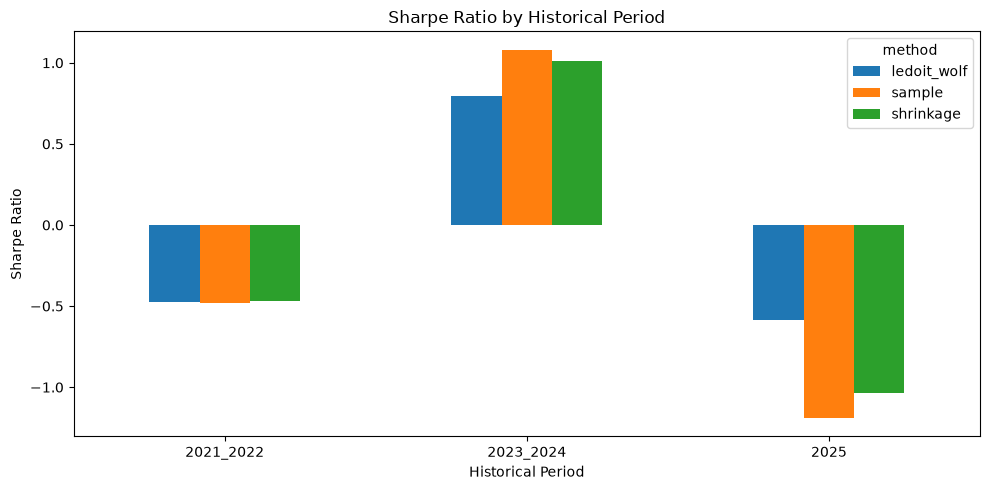

In [40]:
regime_sharpe.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "Sharpe Ratio by Historical Period"
)

plt.xlabel("Historical Period")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

The chart above allows us to visually inspect whether the relative ordering of the covariance methodologies changes across historical periods.

In [41]:
# Let's calculate the average and dispersion of Sharpe ratios across periods
stability_summary = pd.DataFrame(
    {
        "mean_sharpe": regime_sharpe.mean(),
        "median_sharpe": regime_sharpe.median(),
        "std_sharpe": regime_sharpe.std(),
        "min_sharpe": regime_sharpe.min(),
        "max_sharpe": regime_sharpe.max(),
    }
)

stability_summary.sort_values(
    "mean_sharpe",
    ascending=False,
)

,mean_sharpe,median_sharpe,std_sharpe,min_sharpe,max_sharpe
method,,,,,
ledoit_wolf,-0.090550,-0.477502,0.766761,-0.586729,0.792580
shrinkage,-0.164674,-0.466339,1.056232,-1.037256,1.009571
sample,-0.196813,-0.480495,1.161693,-1.190390,1.080446


We will consider:

higher mean Sharpe → stronger average risk-adjusted performance
higher median Sharpe → stronger typical performance
lower standard deviation → greater stability
higher minimum Sharpe → better worst-period resilience

This is particularly useful because a methodology can have the highest average Sharpe but still exhibit considerable instability.

In [42]:
rank_table = regime_sharpe.rank(
    axis=1,
    ascending=False,
    method="min",
)

rank_table

method,ledoit_wolf,sample,shrinkage
period,,,
2021_2022,2.0,3.0,1.0
2023_2024,3.0,1.0,2.0
2025,1.0,3.0,2.0


In [43]:
average_rank = (
    rank_table
    .mean(axis=0)
    .sort_values()
)

average_rank

method
shrinkage      1.666667
ledoit_wolf    2.000000
sample         2.333333
dtype: float64

This converts absolute Sharpe values into relative rankings.

For three methodologies:

1 = best\
2 = second\
3 = third

A lower average rank therefore indicates more consistent relative performance.

In [44]:
regime_stability = pd.DataFrame(
    {
        "mean_sharpe": regime_sharpe.mean(),
        "sharpe_std": regime_sharpe.std(),
        "average_rank": average_rank,
        "regime_wins": (
            regime_sharpe.idxmax(axis=1)
            .value_counts()
        ),
    }
).fillna(0)

regime_stability.sort_values(
    "average_rank"
)

,mean_sharpe,sharpe_std,average_rank,regime_wins
shrinkage,-0.164674,1.056232,1.666667,1
ledoit_wolf,-0.090550,0.766761,2.000000,1
sample,-0.196813,1.161693,2.333333,1


## Regime Stability Matrix

We combine the principal stability measures into a compact research
table.

This provides a concise view of both performance and consistency.

In [45]:
regime_stability = pd.DataFrame(
    {
        "mean_sharpe": regime_sharpe.mean(),
        "sharpe_std": regime_sharpe.std(),
        "average_rank": average_rank,
        "regime_wins": (
            regime_sharpe
            .idxmax(axis=1)
            .value_counts()
        ),
    }
).fillna(0)

regime_stability.sort_values(
    "average_rank"
)

,mean_sharpe,sharpe_std,average_rank,regime_wins
shrinkage,-0.164674,1.056232,1.666667,1
ledoit_wolf,-0.090550,0.766761,2.000000,1
sample,-0.196813,1.161693,2.333333,1


## Research Interpretation

The regime analysis provides an additional validation layer for the
covariance research.

The key distinction is between:

1. performance superiority, and
2. stability of performance superiority.

A methodology that performs best during only one historical period
provides weaker evidence of general superiority than one that remains
competitive across multiple periods.

The regime results are therefore interpreted jointly with:

- the baseline covariance comparison,
- scenario analysis,
- training-window robustness,
- and the broader out-of-sample evidence.

No universal superiority is assumed before examining the empirical
results.

## Regime Stability Conclusion

### Research Question

Does the relative performance of covariance methodologies remain stable
across different historical market periods?

### Evidence

The analysis evaluates:

- annualized return,
- Sharpe ratio,
- maximum drawdown,
- regime-level winners,
- winner frequency,
- Sharpe-ratio dispersion,
- and relative methodology ranking.

### Empirical Finding

[Complete after reviewing the actual regime-level results.]

### Research Implication

[Complete after reviewing the actual regime-level results.]

## Regime Stability Conclusion

The regime analysis shows that covariance-method performance is
market-regime dependent.

During 2021–2022, shrinkage produced the strongest annualized return
and Sharpe ratio, while Ledoit-Wolf produced the least severe maximum
drawdown.

During 2023–2024, the sample covariance estimator was the strongest
method across annualized return, Sharpe ratio, and maximum drawdown.

During 2025, Ledoit-Wolf was the strongest method across all three
measures, although all three methodologies generated negative returns
and negative Sharpe ratios.

The stability analysis further shows that shrinkage achieved the best
average Sharpe-ratio rank (1.67), followed by Ledoit-Wolf (2.00) and
sample covariance (2.33). Each methodology won one of the three
historical regimes.

Therefore, the evidence does not support universal superiority of a
single covariance estimator. Instead, the preferred methodology depends
on the prevailing market regime and the research objective.

This finding strengthens the case for evaluating covariance estimators
using multiple historical periods rather than relying on a single
backtest window.

In [50]:
# Regime conclusion
regime_conclusion = pd.DataFrame(
    {
        "2021_2022": {
            "return_winner": "shrinkage",
            "sharpe_winner": "shrinkage",
            "drawdown_winner": "ledoit_wolf",
        },
        "2023_2024": {
            "return_winner": "sample",
            "sharpe_winner": "sample",
            "drawdown_winner": "sample",
        },
        "2025": {
            "return_winner": "ledoit_wolf",
            "sharpe_winner": "ledoit_wolf",
            "drawdown_winner": "ledoit_wolf",
        },
    }
).T

regime_conclusion

,return_winner,sharpe_winner,drawdown_winner
2021_2022,shrinkage,shrinkage,ledoit_wolf
2023_2024,sample,sample,sample
2025,ledoit_wolf,ledoit_wolf,ledoit_wolf


## Transition to Research Synthesis

The regime analysis completes the historical stability assessment.

The next stage consolidates the evidence from:

1. baseline covariance comparison,
2. scenario analysis,
3. training-window sensitivity,
4. shrinkage sensitivity,
5. robustness analysis, and
6. regime-level evaluation.

The objective is to determine what the combined evidence implies for
practical covariance-method selection.